<a href="https://colab.research.google.com/github/zorGizem/Erken-Evre-Alzhemir-Tespiti/blob/main/notebooks/Aray%C3%BCz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== TEK SEFERLİK TEMİZ KURULUM (her yeni Colab oturumunda çalıştır) =====
# 1) Önce numpy/scipy/pandas'ı SABİTLE (antspyx & HD-BET bunları bozmasın)
!pip install -q "numpy==1.26.4" "scipy==1.12.0" "pandas==2.2.2"

# 2) Sistem aracı
!apt-get install -y dcm2niix -q

# 3) Görüntü işleme kütüphaneleri
!pip install -q antspyx nibabel nilearn

# 4) HD-BET + bağımlılıkları (SimpleITK, batchgenerators dahil)
!git clone https://github.com/MIC-DKFZ/HD-BET
%cd HD-BET
!pip install -q -e .
%cd ..
!pip install -q SimpleITK batchgenerators

# 5) numpy'ı tekrar sabitle (yukarıdakiler kaydırmış olabilir)
!pip install -q "numpy==1.26.4"

print("KURULUM BİTTİ — şimdi: Çalışma zamanı -> Oturumu yeniden başlat")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 14.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires scipy>=1.13, but you have scipy 1.12.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires scipy>=1.13, but you have scipy 1.12.0 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, 

In [ ]:
import ants
import nibabel
print("ANTs OK ✓", ants.__version__)

ANTs OK ✓ 0.6.3


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/KOÜ DERSLER/2025-2026 BAHAR/BİTİRME ÇALIŞMALARI/GizemZor/YAZILIM_TASARIMI/Bitirme/Kodlar/notebooks/uygulama')  # <-- KENDİ klasör yolun

from preprocessing_pipeline import preprocess_subject, PipelineConfig
print("Araç kutusu yüklendi ✓")

Araç kutusu yüklendi ✓


In [ ]:
# HD-BET'in kalan bağımlılıkları + numpy'ı sabitle
!pip install -q SimpleITK batchgenerators acvl_utils dynamic_network_architectures nnunetv2 "numpy==1.26.4"

In [ ]:
# HD-BET'in eksik bağımlılıklarını numpy'a dokunmadan ekle
!pip install -q batchgenerators
import importlib, HD_BET  # eksik başka modül var mı diye dene

In [ ]:
import numpy as np
print("numpy:", np.__version__)   # 1.26.4 olmalı
import ants
print("ANTs OK ✓")

In [ ]:
cfg = PipelineConfig(
    mni_template_path='/content/drive/MyDrive/KOÜ DERSLER/2025-2026 BAHAR/BİTİRME ÇALIŞMALARI/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/mni152_brain_1mm.nii.gz',
    device='cuda:0',
    cleanup_intermediate=False,   # ara çıktıları da görelim
)

sonuc = preprocess_subject(
    dicom_dir='/content/drive/MyDrive/KOÜ DERSLER/2025-2026 BAHAR/BİTİRME ÇALIŞMALARI/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Original/original_EMCI/009_S_4530/MPRAGE/2012-02-14_18_30_35.0/I284904',
    config=cfg,
)

print("\nKesit klasörü:", sonuc.slice_dir)
for duzlem, yollar in sonuc.slice_paths.items():
    print(f"  {duzlem}: {len(yollar)} kesit")

[pipeline] Çalışma klasörü: /tmp/subject_23ulu3gl
[pipeline] ADIM 1 OK: DICOM -> NIfTI (subject.nii.gz)
[pipeline] ADIM 2 OK: N4 Bias Field Correction
[pipeline] ADIM 3 OK: Skull Stripping (HD-BET)
[pipeline] ADIM 4 OK: MNI Registration (beyin + maske)
[pipeline] ADIM 5 OK: Z-Score Normalizasyon
[pipeline] ADIM 6 OK: Slicing — 30 kesit üretildi
[pipeline] PIPELINE TAMAMLANDI ✓

Kesit klasörü: /tmp/subject_23ulu3gl/06_slices
  koronal: 10 kesit
  aksiyal: 10 kesit
  sagital: 10 kesit


In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Her düzlemden ortadaki bir kesidi göster
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, duzlem in zip(axes, ['sagital', 'aksiyal', 'koronal']):
    yol = sonuc.slice_paths[duzlem][5]   # 6. kesit (ortadan)
    veri = nib.load(yol).get_fdata().squeeze()
    ax.imshow(veri.T, cmap='gray', origin='lower')
    ax.set_title(f"{duzlem} (kesit 6)")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import nibabel as nib, numpy as np

p_yeni = sonuc.slice_paths['sagital'][5]
v_yeni = nib.load(p_yeni).get_fdata().squeeze()

# Eğitim/test Slice klasöründen aynı hastanın hazır kesidi:
p_egitim = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI/009_S_4530/2012-02-14_18_30_35.0/sagital_06.nii.gz'
v_egitim = nib.load(p_egitim).get_fdata().squeeze()

print("YENİ   -> boyut:", v_yeni.shape, "| min:", round(float(v_yeni.min()),2), "max:", round(float(v_yeni.max()),2))
print("EĞİTİM -> boyut:", v_egitim.shape, "| min:", round(float(v_egitim.min()),2), "max:", round(float(v_egitim.max()),2))

In [ ]:
import numpy as np
print(np.__version__)

In [ ]:
deney = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_16_27'  # <-- KENDİ klasör yolun
import os
for kok, klasorler, dosyalar in os.walk(deney):
    seviye = kok.replace(deney, '').count(os.sep)
    print('  ' * seviye, os.path.basename(kok) + '/')
    for f in sorted(dosyalar):
        print('  ' * (seviye+1), f)

In [ ]:
from inference_pipeline import InferenceConfig, load_models, predict_subject
print("Inference modülü yüklendi ✓")

Inference modülü yüklendi ✓


In [ ]:
icfg = InferenceConfig(
    model_klasoru='/content/drive/MyDrive/KOÜ DERSLER/2025-2026 BAHAR/BİTİRME ÇALIŞMALARI/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_16_27',
    mod="tek_duzlem",
    aktif_duzlem="auto",
)
modeller = load_models(icfg)
tahmin_sonuc = predict_subject(sonuc.slice_dir, icfg, modeller)

print(f"\nTahmin : {tahmin_sonuc.tahmin}")
print(f"Güven  : {tahmin_sonuc.guven:.1%}")
print(f"Olasılıklar: {tahmin_sonuc.olasiliklar}")

[inference] Düzlem val_acc ort: sagital=0.713, aksiyal=0.683, koronal=0.693
[inference] Seçilen düzlem: sagital
[inference] sagital foldları yükleniyor...
[inference] Yüklendi: 5 model (1 düzlem x 5 fold)

Tahmin : EMCI
Güven  : 96.8%
Olasılıklar: {'CN': 0.0316434249753407, 'EMCI': 0.9683565750246593}


In [ ]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/KOÜ DERSLER/2025-2026 BAHAR/BİTİRME ÇALIŞMALARI/GizemZor/YAZILIM_TASARIMI/Bitirme/Kodlar/notebooks/uygulama') # Ensure path is added
from gradcam_pipeline import generate_gradcam, plot_gradcam_grid, en_onemli_kesitler
print("Grad-CAM modülü yüklendi ✓")

Grad-CAM modülü yüklendi ✓


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import importlib, sys
sys.path.append('/content/drive/MyDrive/KOÜ DERSLER/2025-2026 BAHAR/BİTİRME ÇALIŞMALARI/GizemZor/YAZILIM_TASARIMI/Bitirme/Kodlar/notebooks/uygulama')

# Önbelleği temizle ki yeni dosyayı görsün
importlib.invalidate_caches()

from gradcam_pipeline import generate_gradcam, plot_gradcam_grid, en_onemli_kesitler
print("Grad-CAM modülü yüklendi ✓")

Mounted at /content/drive
Grad-CAM modülü yüklendi ✓


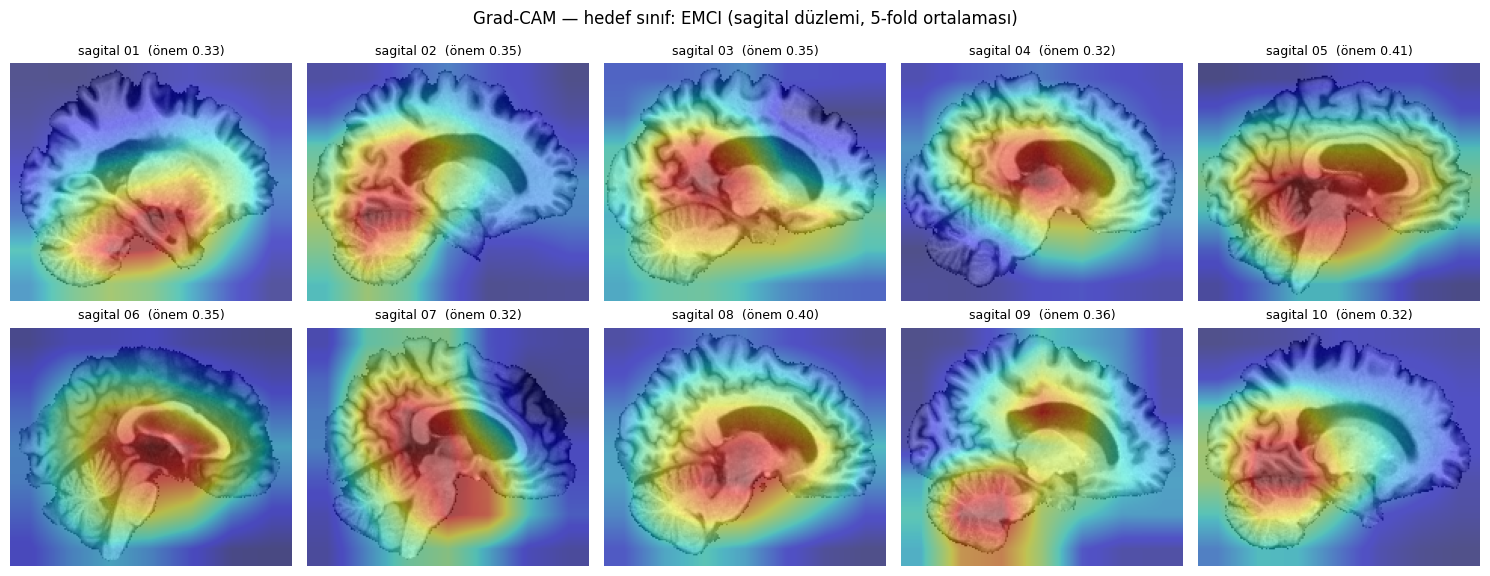

En önemli kesitler (indeks): [4, 7, 8]


In [ ]:
gc = generate_gradcam(
    slice_dir=sonuc.slice_dir,   # Faz 1 çıktısı
    config=icfg,
    modeller=modeller,           # Faz 2'de yüklenen modeller
    hedef_duzlem="sagital",      # seçilen düzlem (None verirsen otomatik ilk düzlemi alır)
    hedef_sinif=1,               # 1 = EMCI (pozitif tespit). CN için 0.
)

plot_gradcam_grid(gc)            # 10 kesidi grid halinde göster

# Modelin en çok odaklandığı 3 kesit:
print("En önemli kesitler (indeks):", en_onemli_kesitler(gc, k=3))

In [ ]:
import os
klasor = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Kodlar/notebooks/uygulama'
print("Klasördeki dosyalar:")
for f in sorted(os.listdir(klasor)):
    print(" ", f)

In [ ]:
!pip install -q gradio

In [ ]:
import importlib, app_gradio
importlib.reload(app_gradio)   # her güncellemede taze yükle
from app_gradio import build_app

app = build_app(
    mni_template_path='/content/drive/MyDrive/KOÜ DERSLER/2025-2026 BAHAR/BİTİRME ÇALIŞMALARI/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/mni152_brain_1mm.nii.gz',
    model_klasoru='/content/drive/MyDrive/KOÜ DERSLER/2025-2026 BAHAR/BİTİRME ÇALIŞMALARI/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_16_27',
    device='cuda:0',
)
app.launch(share=True)   # share=True -> herkesin erişebileceği public link verir

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b03addaed8fa0622e7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import os
klasor = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Kodlar/notebooks/uygulama'
print([f for f in os.listdir(klasor) if f.endswith('.py')])

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import importlib
importlib.invalidate_caches()

import app_gradio
importlib.reload(app_gradio)
from app_gradio import build_app
print("Arayüz modülü yüklendi ✓")

In [ ]:
app = build_app(
    mni_template_path='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/mni152_brain_1mm.nii.gz',
    model_klasoru='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_16_27',
    device='cuda:0',
)
app.launch(share=True)